# Heart Stroke Prediction

**Life cycle of Machine learning Project**

- [✔] Understanding the Problem Statement
- [✔] Data Collection
- [✔] Data Cleaning
- [✔] Exploratory Data Analysis
- [o] Data Pre-Processing
- [o] Model Training
- [o] Choose best model

## Problem statement

- in the proposed model, heart stroke prediction is peformed on a dataset collected from kaggle. the model predicts the chances a person will have stroke based on symptoms like age, gender, average glucose level, smoking status, body mass index, work type and residence type.

### Library version problem

In [2]:
import matplotlib
import pandas as pd
import numpy as np
import seaborn as sns

print("Seaborn version: ",sns.__version__)
print("Numpy version: ",np.__version__)
print("Matplotlib version: ",matplotlib.__version__)

# Seaborn version:  0.12.2 # this gives bar plot color, but heatmap have error
# Numpy version:  1.24.4
# Seaborn version:  0.13.0 # this gives bar plot no color , but heatmap no error solved

# matplot version : 3.7.3
# 3 solves all the problems

Seaborn version:  0.12.2
Numpy version:  1.24.4
Matplotlib version:  3.7.3


## Imports

In [3]:
from src.analyze.basic_data_inspection import (DataInspector,
                                               DataTypesInspectionStrategy,
                                               SummaryStatisticsInspectionStrategy,
                                               )

from src.analyze.univariate.numerical import NumericalUnivariate
from src.analyze.univariate.categorical import CategoricalUnivariate
from src.analyze.bivariate.num_num import NumericalNumericalBivariate
from src.analyze.bivariate.num_cat import CategoricalNumericalBivariate
from src.analyze.bivariate.cat_cat import CategoricalCategoricalBivariate

# Set display options for better readability
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

## Reading Data

**Import the CSV Data as Pandas DataFrame**

In [4]:
df = pd.read_csv(f"data/heart_stroke_data.csv")

### **Show Top 5 Records**

In [5]:
df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,male,67.0,0,1,yes,private,urban,228.69,36.6,formerly_smoked,1
1,51676,female,61.0,0,0,yes,self_employed,rural,202.21,-1.0,never_smoked,1
2,31112,male,80.0,0,1,yes,private,rural,105.92,32.5,never_smoked,1
3,60182,female,49.0,0,0,yes,private,urban,171.23,34.4,not_available,1
4,1665,female,79.0,1,0,yes,self_employed,rural,174.12,24.0,never_smoked,1


### **Feature Information**

- Here we used the heart stroke dataset that is available in the kaggle website for our analysis. This datasets consists of total 12 attributes. The complete description of the attributes used in the proposed work is given below.

- **id**: This attribute means person's id. it's numerical data.

- **Age**: This attribute means a persons age. it's numerical data.

- **Gender**: This attribute means a person's gender, it's categorical data.

- **Hypertension**: This attribute means that this person is hypertensive or not. it's numerical data.

- **work type**: This attribute represents the person work scenario. it's categorical data.

- **residence type**: This attribute represnts the person work scenario. it's categorical data.

- **heart disease**: This attribute means wheather this person has a heart disease person or not. it's numerical data.

- **avg_glucose_level**: This attribute means what was the level of a person's glucose condition. it's numercial data.

- **Bmi**: This attribute represents a person's married status. it's categorical data.

- **ever_married**: This attribute represents a person's married status. it's categorical data.

- **smoking_status**: This attribute means a person's smoking condition. it's categorical data.

- **Stroke**: This attribute means a person previously had a choise or not.

### **Shape of the dataset**

In [6]:
df.shape

(5110, 12)

In [7]:
inspector = DataInspector(DataTypesInspectionStrategy())
inspector.execute_inspection(df)


Data Types and Non-null Counts:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                5110 non-null   float64
 10  smoking_status     3566 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB
None


### **Summary of the dataset**

In [8]:
inspector.set_strategy(SummaryStatisticsInspectionStrategy())
inspector.execute_inspection(df)


Summary Statistics (Numerical Features):
                 id          age  hypertension  heart_disease  \
count   5110.000000  5110.000000   5110.000000    5110.000000   
mean   36517.829354    43.226614      0.097456       0.054012   
std    21161.721625    22.612647      0.296607       0.226063   
min       67.000000     0.080000      0.000000       0.000000   
25%    17741.250000    25.000000      0.000000       0.000000   
50%    36932.000000    45.000000      0.000000       0.000000   
75%    54682.000000    61.000000      0.000000       0.000000   
max    72940.000000    82.000000      1.000000       1.000000   

       avg_glucose_level          bmi       stroke  
count        5110.000000  5110.000000  5110.000000  
mean          106.147677    27.717397     0.048728  
std            45.283560     9.645369     0.215320  
min            55.120000    -1.000000     0.000000  
25%            77.245000    22.900000     0.000000  
50%            91.885000    27.700000     0.000000  
7

In [9]:
# visualize target

## **Statistical Inferences**

- Median age of population is 43 years.
- 25% of the population is aged below 25
- Another 25% is aged above 60 and remaining in between threse ages
- About 9.7% and 5.4% of population suffers from hypertension with heart disease respectively.
- People with higher BMI (BMI > 45) are less represented. This can affect our machine learning models significantly.

## **Correcting feature categarization :**

In [10]:
TARGET_COL = ["stroke"]
ID_COL = ["id"]
# TEXT_FEATURES = ["Name"]
CAT_FEATURES = [col for col in df.columns if df[col].dtype == "O" if col not in TARGET_COL+ID_COL]
NUM_FEATURES = [col for col in df.columns if df[col].dtype != "O" if col not in TARGET_COL+ID_COL]

In [11]:
print("id column: ", ID_COL)
print("target column: ", TARGET_COL)
print("categorical columns: ", CAT_FEATURES)
print("numerical columns: ", NUM_FEATURES)

id column:  ['id']
target column:  ['stroke']
categorical columns:  ['gender', 'ever_married', 'work_type', 'residence_type', 'smoking_status']
numerical columns:  ['age', 'hypertension', 'heart_disease', 'avg_glucose_level', 'bmi']


In [12]:
TARGET_COL = ["stroke"]
ID_COL = ["id"]
CAT_FEATURES = ['gender', 'hypertension', 'heart_disease', 'ever_married', 'work_type', 'residence_type', 'smoking_status']
NUM_FEATURES = ['age', 'avg_glucose_level', 'bmi']

## **Missing Value Check :**

In [13]:
df.replace(['not_available', -1], pd.NA).isna().sum()

id                      0
gender                  0
age                     0
hypertension            0
heart_disease           0
ever_married            0
work_type               0
residence_type          0
avg_glucose_level       0
bmi                   201
smoking_status       2333
stroke                  0
dtype: int64

In [14]:
df.replace(['not_available', -1], pd.NA).isna().sum()/df.shape[0] * 100

id                    0.000000
gender                0.000000
age                   0.000000
hypertension          0.000000
heart_disease         0.000000
ever_married          0.000000
work_type             0.000000
residence_type        0.000000
avg_glucose_level     0.000000
bmi                   3.933464
smoking_status       45.655577
stroke                0.000000
dtype: float64

- Around 4% of the BMI data is missing in the dataset
- Smoking habit information is missing for 45% of the population

# Univariate Analysis

In [15]:
# Initialize Analyzers
num_uni = NumericalUnivariate(df)

## Numerical Variables

In [16]:
NUM_FEATURES

['age', 'avg_glucose_level', 'bmi']

**Age**

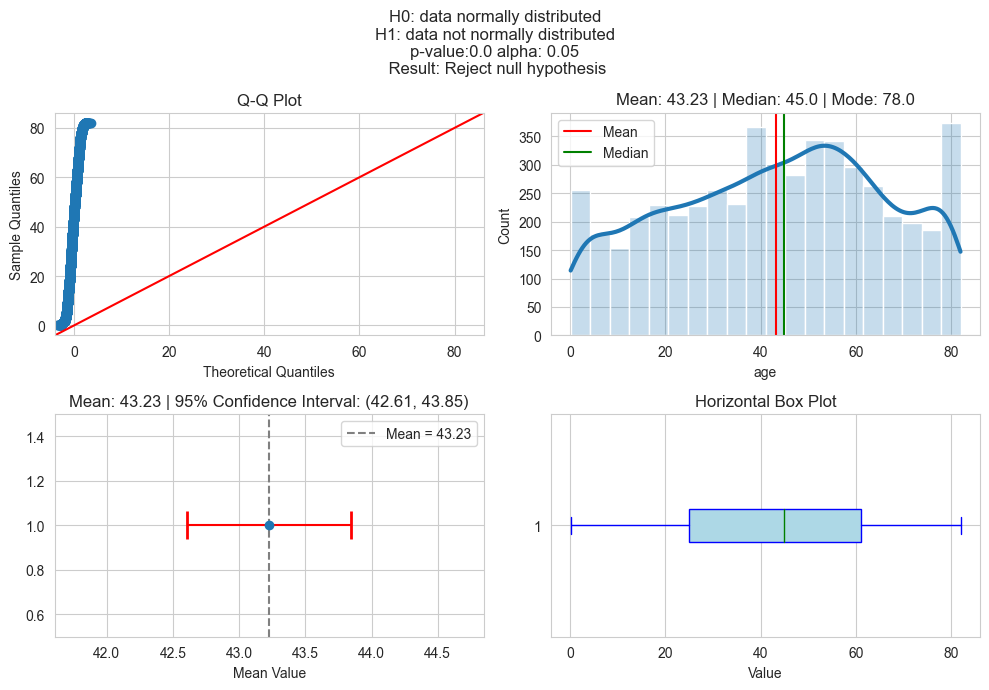

In [17]:
num_uni.plot_numerical_summary("age")

**Avg Glucose Level** 

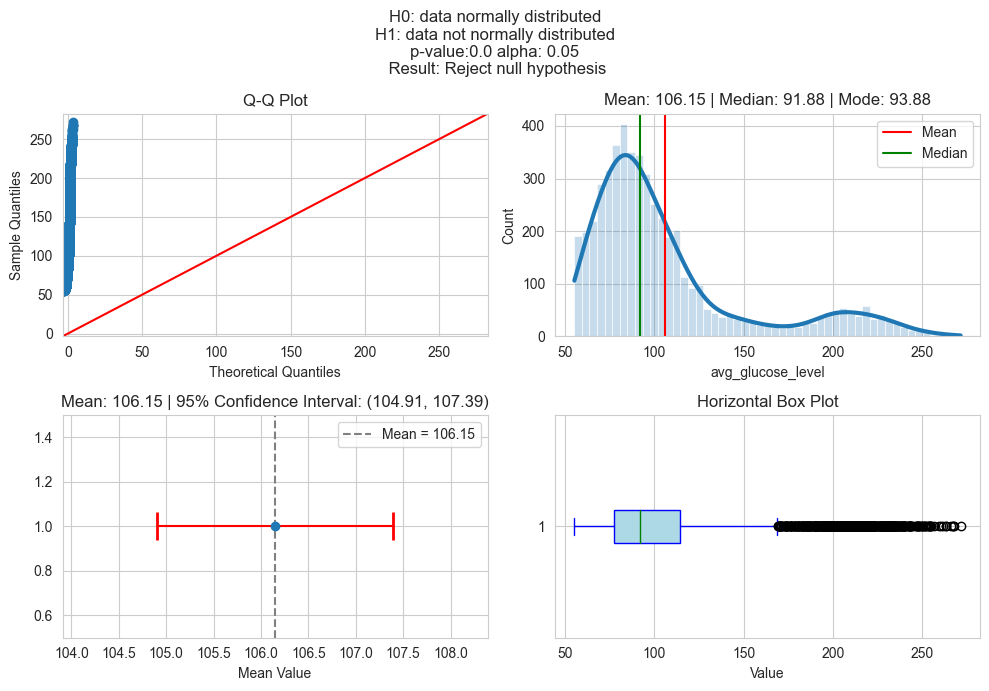

In [18]:
num_uni.plot_numerical_summary("avg_glucose_level")

**BMI**

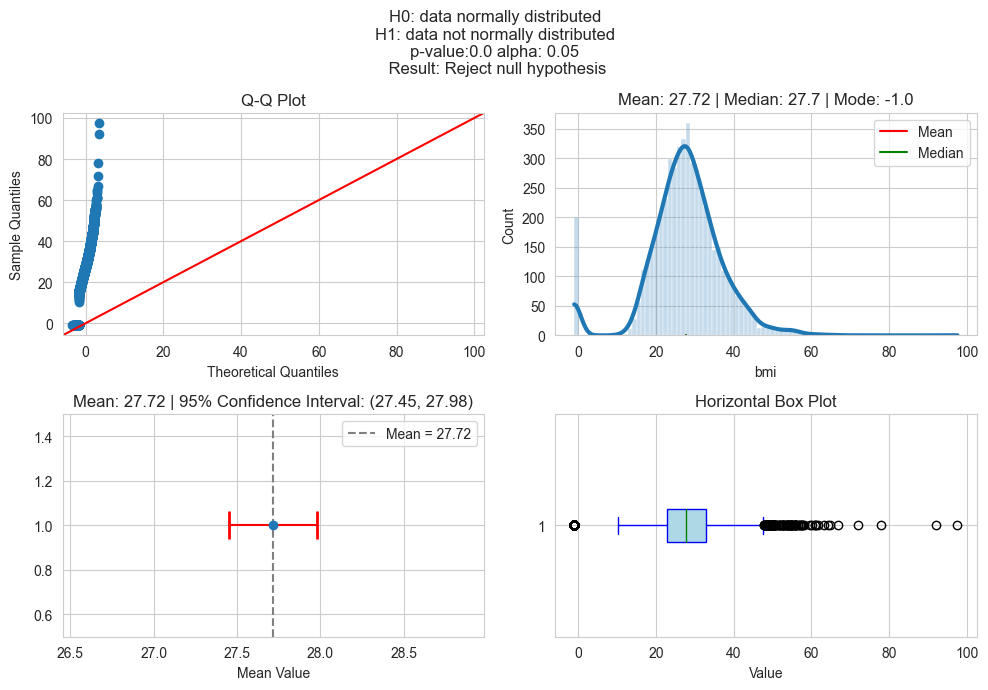

In [19]:
num_uni.plot_numerical_summary("bmi")

**Conclusion:**

- `age`, `avg_glucose_level` and `bmi` are not normally distributed
- `avg_glucose_level` and `bmi` are right skewed with lots of outliers

**Variables** | **Distribution** | **Skewness** | **Outliers** | **Missing**
---|---|---|---|---
age | Not Normal | Left | No | No
avg_glucose_level | Not Normal | Right | Yes | No
bmi | Not Normal | Right | Yes | Yes

**Suggestion:**

- Non-parametric test's are preferable for bivariate analysis
- Try: `log1p`, `sqrt`, `box-cox`, `yeo–johnson`are possible transformation

## Categorical Variables

- stroke
- gender
- hypertension
- heart_disease
- ever_married
- work_type
- Residence_type
- smoking_status

In [20]:
CAT_FEATURES

['gender',
 'hypertension',
 'heart_disease',
 'ever_married',
 'work_type',
 'residence_type',
 'smoking_status']

In [21]:
cat_uni = CategoricalUnivariate(df)

**stroke**

In [22]:
cat_uni.bootstrap_expected_distribution(df, 'stroke')

stroke
0    0.951119
1    0.048881
dtype: float64

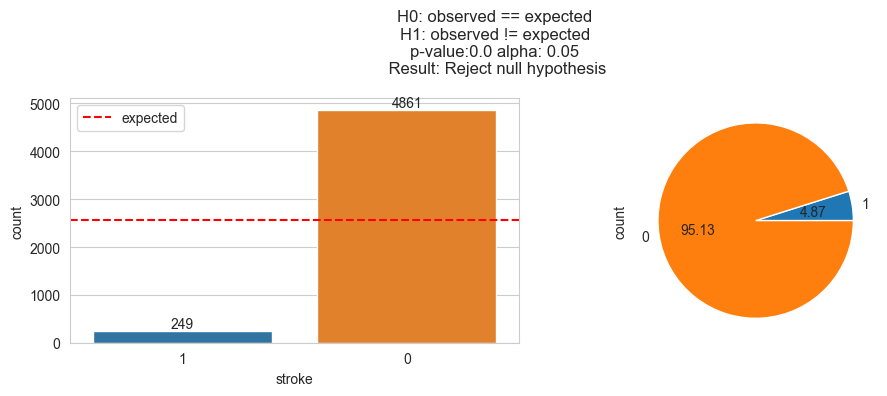

In [23]:
cat_uni.plot_categorical_summary(df, "stroke")

- nearly 5% of total population is having heart attacks

**gender**

In [24]:
cat_uni.bootstrap_expected_distribution(df, 'gender')

gender
female    0.586200
male      0.413599
other     0.000202
dtype: float64

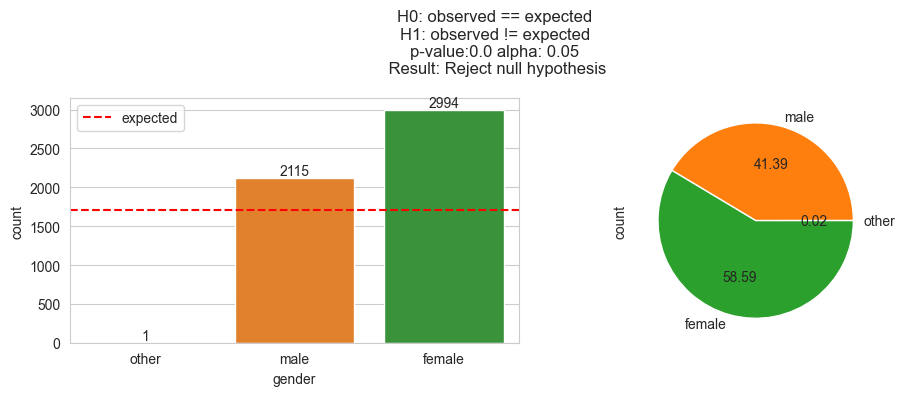

In [25]:
cat_uni.plot_categorical_summary(df, "gender")

- there are male and females with 60:40 distribution respectively
- `other` has only one record, that can be dropped

**hypertension**

In [26]:
cat_uni.bootstrap_expected_distribution(df, 'hypertension', 10000)

hypertension
0    0.902531
1    0.097469
dtype: float64

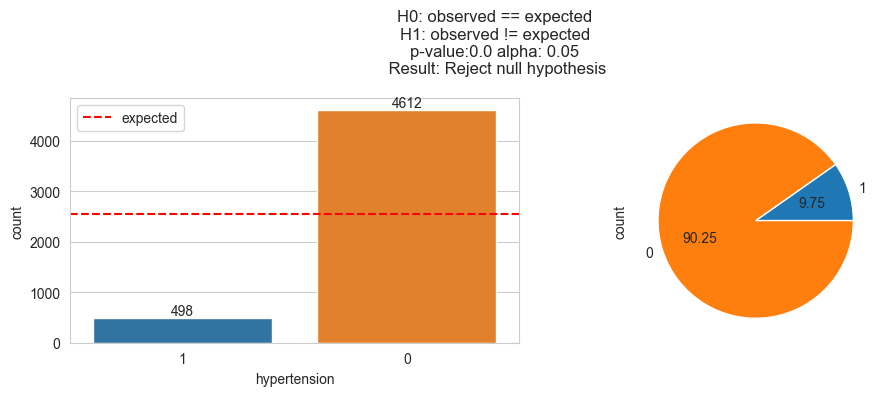

In [27]:
cat_uni.plot_categorical_summary(df, "hypertension")

- 10% of population suffering from hypertnesion

**heart_disease**

In [28]:
cat_uni.bootstrap_expected_distribution(df, 'heart_disease', 10000)

heart_disease
0    0.94597
1    0.05403
dtype: float64

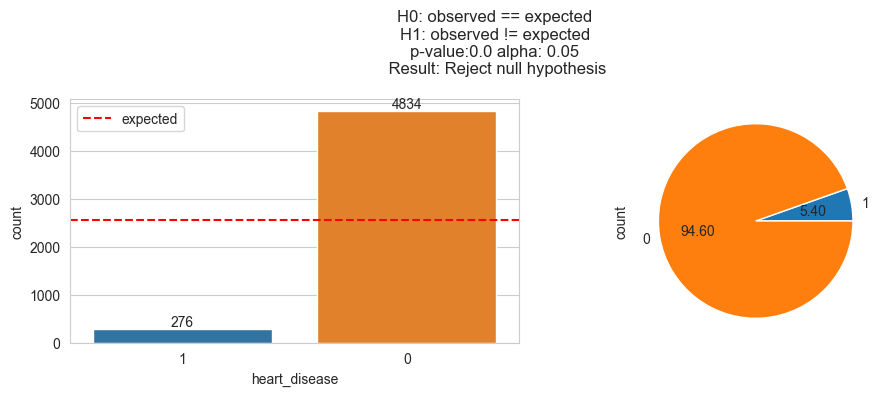

In [29]:
cat_uni.plot_categorical_summary(df, "heart_disease")

- 5-6% of population suffering heart disease

**ever_married**

In [30]:
cat_uni.bootstrap_expected_distribution(df, 'ever_married', 10000)

ever_married
yes    0.65621
no     0.34379
dtype: float64

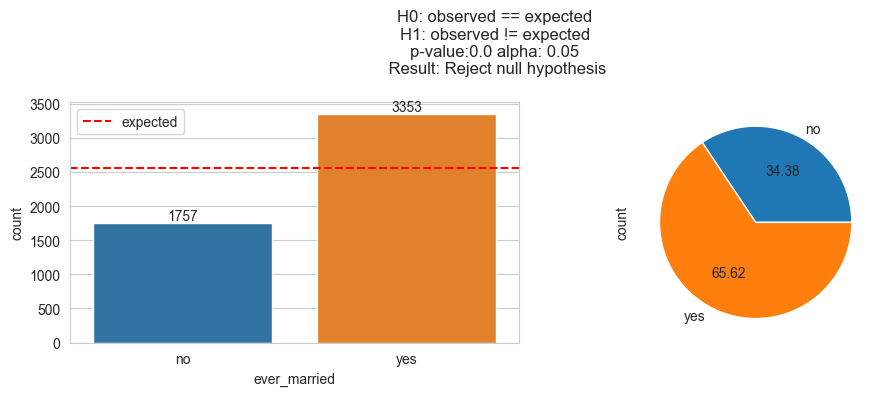

In [31]:
cat_uni.plot_categorical_summary(df, "ever_married")

- 65% of the population is commited

**work_type**

In [32]:
cat_uni.bootstrap_expected_distribution(df, 'work_type', 10000)

work_type
private          0.572361
self_employed    0.160267
govt_job         0.128581
children         0.134477
never_worked     0.004314
dtype: float64

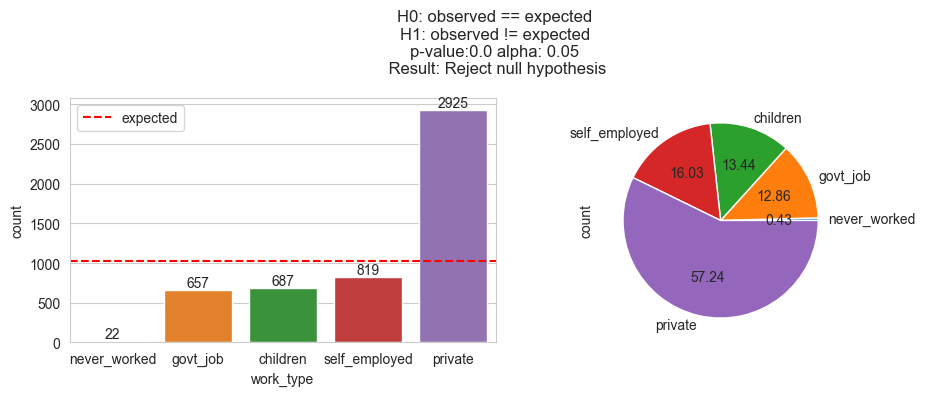

In [33]:
cat_uni.plot_categorical_summary(df, "work_type")

- ~57% of population work for `private` organizations
- ~16% are `self-employeed`
- ~14% are `children`
- ~12% work for `government`
- < 1% of population `never worked`

**Suggestion:**

- can combine `children` and `never_worked` categories (but check their ages).

**Residence_type**

In [34]:
cat_uni.bootstrap_expected_distribution(df, 'residence_type', 10000)

residence_type
urban    0.508043
rural    0.491957
dtype: float64

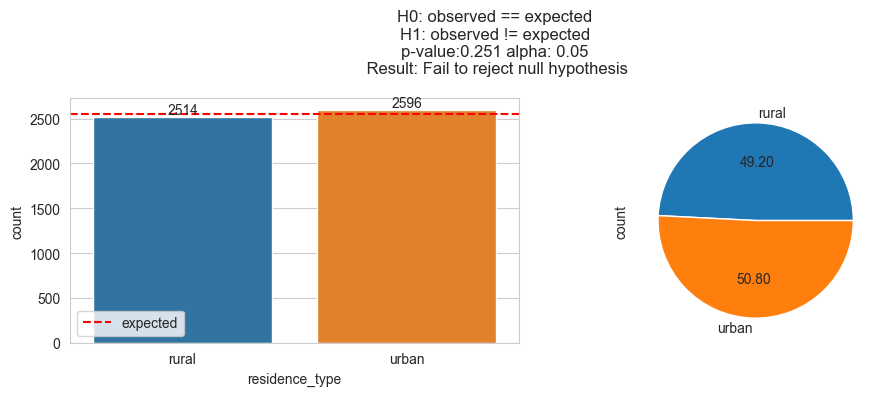

In [35]:
cat_uni.plot_categorical_summary(df, "residence_type")

- population is equally distributed between `Rural` and `Urban` region

**smoking_status**

In [36]:
cat_uni.bootstrap_expected_distribution(df, 'smoking_status', 10000)

smoking_status
never_smoked       0.530713
formerly_smoked    0.248107
not_available      0.221181
dtype: float64

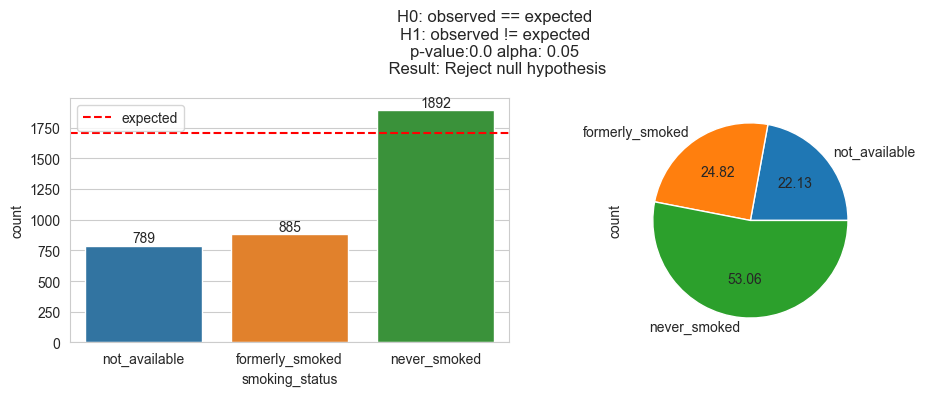

In [37]:
cat_uni.plot_categorical_summary(df, "smoking_status")

- ~54% population `never smoked`
- `don't know` about 22% of population
- 25% of population `used_to_smoke`, but has quit.

### **Conclusion:**

**Variables** | **Distribution** | **Missing**
---|---|---
stroke | Imbalanced | No
gender | Imbalanced | No
hypertension | Imbalanced | No
heart_disease | Imbalanced | No 
ever_married | Imbalanced | No 
work_type | Imbalanced | No 
residence_type | Balanced | No 
smoking_status | Imbalanced | Yes

# Bivariate Analysis

## 1. Categorical - Numerical

- stroke Vs age
- stroke Vs avg_glucose_level
- stroke Vs bmi

In [38]:
cat_num_bi = CategoricalNumericalBivariate(df)

### 1. Stroke Vs Age

In [39]:
cat_num_bi.create_agg_table("stroke", "age")


--- Aggregation Table for 'age' grouped by 'stroke' ---


,mean,median,std,count,min,max
stroke,,,,,,
0,41.97,43.0,22.29,4861,0.08,82.0
1,67.73,71.0,12.73,249,1.32,82.0


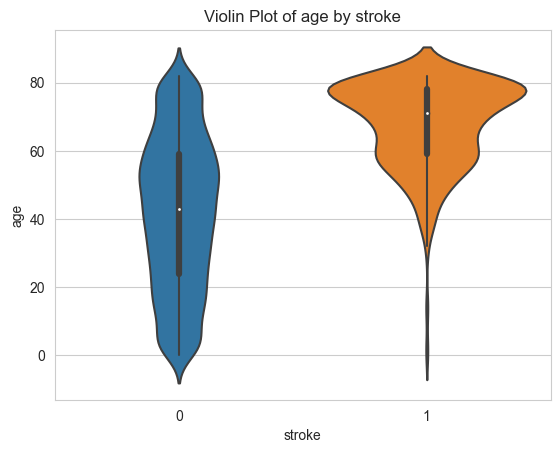

In [40]:
cat_num_bi.plot_violinplot_sns("stroke", "age")

In [41]:
cat_num_bi.plot_boxplot_plotly("stroke", "age")

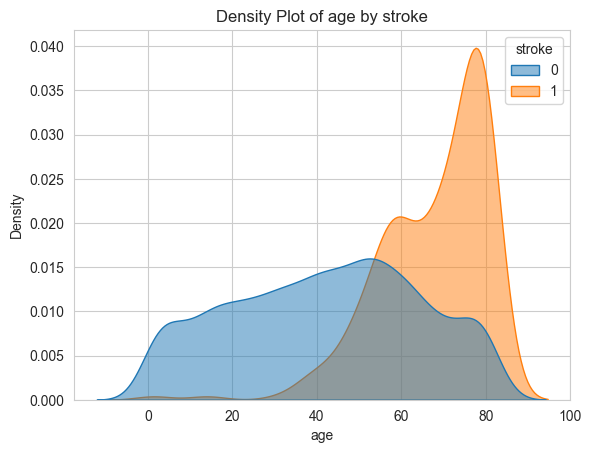

In [42]:
cat_num_bi.plot_density_by_category("stroke", "age")

In [43]:
cat_num_bi.test_group_means("stroke", "age")


--- Testing Mean Difference for age across stroke groups ---
Test used: Independent Samples T-test
Statistic: 18.0808, P-value: 0.0000
Result: Significant difference found between at least two group means.


In [44]:
cat_num_bi.suggest_imputation_strategy("stroke", "age")

Prescriptive Insight: There is a significant difference in age across stroke.
Recommendation: Impute missing values in age using group-specific means/medians (e.g., impute HR salaries with the HR mean salary).


### 2. Stroke Vs Avg Glucose Level

In [45]:
cat_num_bi.create_agg_table("stroke", "avg_glucose_level")


--- Aggregation Table for 'avg_glucose_level' grouped by 'stroke' ---


,mean,median,std,count,min,max
stroke,,,,,,
0,104.80,91.47,43.85,4861,55.12,267.76
1,132.54,105.22,61.92,249,56.11,271.74


In [46]:
cat_num_bi.plot_boxplot_plotly("stroke", "avg_glucose_level")

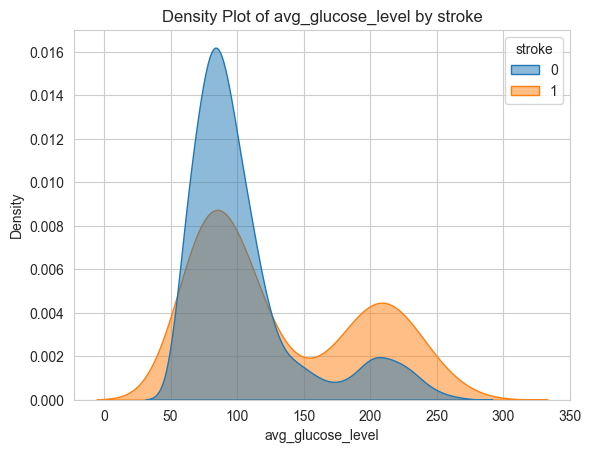

In [47]:
cat_num_bi.plot_density_by_category("stroke", "avg_glucose_level")

In [48]:
cat_num_bi.test_group_means("stroke", "avg_glucose_level")


--- Testing Mean Difference for avg_glucose_level across stroke groups ---
Test used: Independent Samples T-test
Statistic: 9.5134, P-value: 0.0000
Result: Significant difference found between at least two group means.


In [49]:
cat_num_bi.suggest_imputation_strategy("stroke", "avg_glucose_level")

Prescriptive Insight: There is a significant difference in avg_glucose_level across stroke.
Recommendation: Impute missing values in avg_glucose_level using group-specific means/medians (e.g., impute HR salaries with the HR mean salary).


- with outliers it's hard to conlude, that glucose levels are really contirbuting in getting stroke

### 3. Stroke Vs BMI

In [50]:
cat_num_bi.create_agg_table("stroke", "bmi")


--- Aggregation Table for 'bmi' grouped by 'stroke' ---


,mean,median,std,count,min,max
stroke,,,,,,
0,27.84,27.7,9.43,4861,-1.0,97.6
1,25.42,28.1,12.95,249,-1.0,56.6


In [51]:
cat_num_bi.plot_boxplot_plotly("stroke", "bmi")

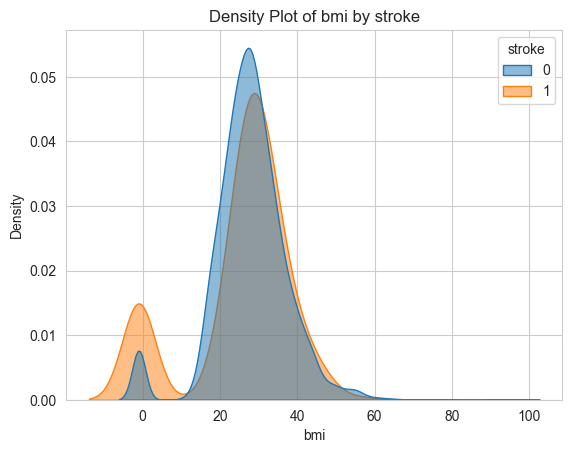

In [52]:
cat_num_bi.plot_density_by_category("stroke", "bmi")

In [53]:
cat_num_bi.test_group_means("stroke", "bmi")


--- Testing Mean Difference for bmi across stroke groups ---
Test used: Independent Samples T-test
Statistic: -3.8661, P-value: 0.0001
Result: Significant difference found between at least two group means.


In [54]:
cat_num_bi.suggest_imputation_strategy("stroke", "bmi")

Prescriptive Insight: There is a significant difference in bmi across stroke.
Recommendation: Impute missing values in bmi using group-specific means/medians (e.g., impute HR salaries with the HR mean salary).


## **Final Conclusion:**

**Feature** | **Relation with Stroke**
--- | ---
 Age | Yes
 Avg Glucose Level | Yes (outliers present)
 BMI | Yes (outliers & missing values present)

## 2. Categorical - Categorical

- Stroke Vs. Gender - categorical
- Stroke Vs. Hypertension - categorical
- Stroke Vs. Heart Disease - numerical
- Stroke Vs. Ever Married - numerical
- Stroke Vs. Work Type - categorical
- Stroke Vs. Residence Type - categorical
- Stroke Vs. Smoking Status - categorical


In [55]:
cat_cat_bva = CategoricalCategoricalBivariate(df)

### 1. Stroke Vs Gender

In [56]:
cat_cat_bva.create_contingency_table("stroke", "gender")


--- Contingency Table (Counts) for stroke vs gender ---


gender,female,male,other
stroke,,,
0,2853,2007,1
1,141,108,0


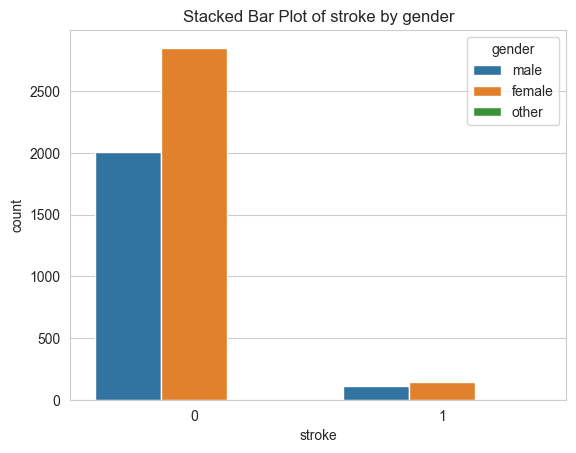

In [57]:
cat_cat_bva.plot_stacked_barplot_sns("stroke", "gender")

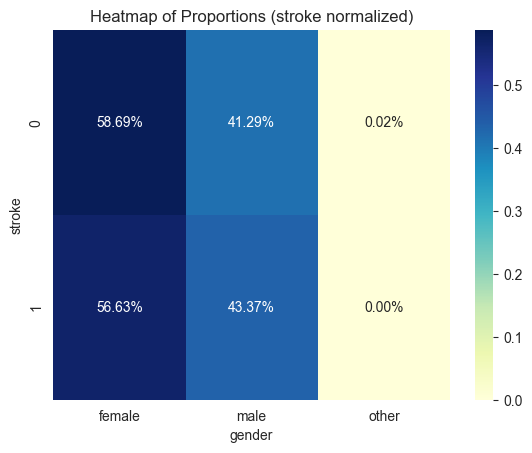

In [58]:
cat_cat_bva.plot_heatmap_contingency("stroke", "gender")

In [59]:
cat_cat_bva.test_chi_squared_independence("stroke", "gender")


--- Chi-squared Test for Independence (stroke vs gender) ---
Chi2 Statistic: 0.4726
P-value: 0.7895
Degrees of Freedom: 2
Result: No significant dependence found (fail to reject H0). Variables are likely independent.


In [60]:
cat_cat_bva.calculate_cramers_v("stroke", "gender")


--- Cramer's V Association Strength (stroke vs gender) ---
Cramer's V: 0.0096


0.009616792928620093

- gender doesn't have any significant impact on stroke

### 2. Stroke Vs. Hypertension

In [61]:
cat_cat_bva.create_contingency_table("stroke", "hypertension")


--- Contingency Table (Counts) for stroke vs hypertension ---


hypertension,0,1
stroke,,
0,4429,432
1,183,66


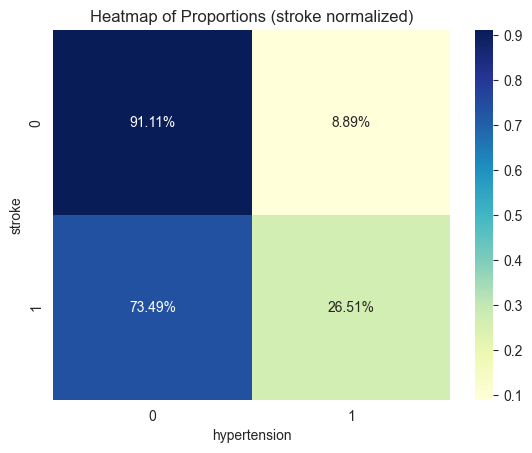

In [62]:
cat_cat_bva.plot_heatmap_contingency("stroke", "hypertension")

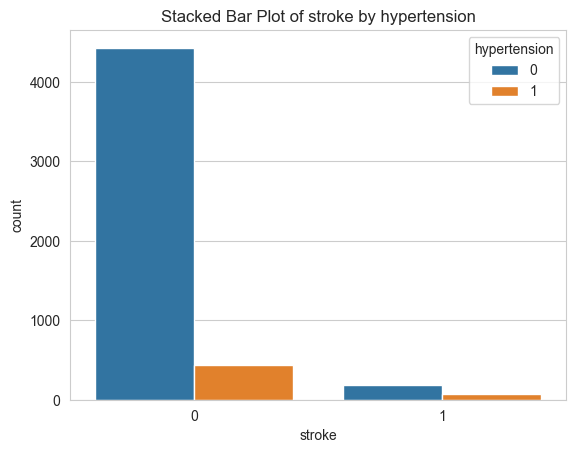

In [63]:
cat_cat_bva.plot_stacked_barplot_sns("stroke", "hypertension")

In [64]:
cat_cat_bva.test_chi_squared_independence("stroke", "hypertension")


--- Chi-squared Test for Independence (stroke vs hypertension) ---
Chi2 Statistic: 81.6054
P-value: 0.0000
Degrees of Freedom: 1
Result: Significant dependence found (reject H0). There IS a relationship between the variables.


In [65]:
cat_cat_bva.calculate_cramers_v("stroke", "hypertension")


--- Cramer's V Association Strength (stroke vs hypertension) ---
Cramer's V: 0.1264


0.12637143420578723

- hypertenssion have relation with heart stroke

### 3. Stroke Vs. Heart Disease

In [66]:
cat_cat_bva.create_contingency_table("stroke", "heart_disease")


--- Contingency Table (Counts) for stroke vs heart_disease ---


heart_disease,0,1
stroke,,
0,4632,229
1,202,47


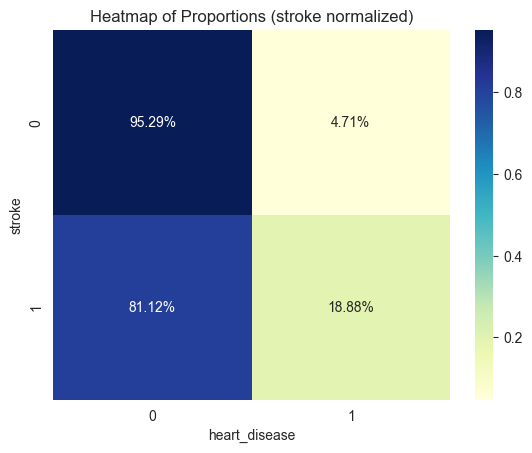

In [67]:
cat_cat_bva.plot_heatmap_contingency("stroke", "heart_disease")

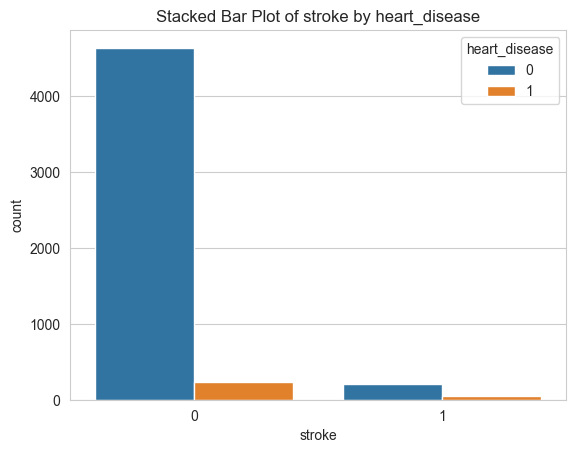

In [68]:
cat_cat_bva.plot_stacked_barplot_sns("stroke", "heart_disease")

In [69]:
cat_cat_bva.test_chi_squared_independence("stroke", "heart_disease")


--- Chi-squared Test for Independence (stroke vs heart_disease) ---
Chi2 Statistic: 90.2596
P-value: 0.0000
Degrees of Freedom: 1
Result: Significant dependence found (reject H0). There IS a relationship between the variables.


In [70]:
cat_cat_bva.calculate_cramers_v("stroke", "heart_disease")


--- Cramer's V Association Strength (stroke vs heart_disease) ---
Cramer's V: 0.1329


0.13290342068079442

- heart disease has significant relation with heart stroke

### 4. Stroke Vs. Ever Married

In [71]:
cat_cat_bva.create_contingency_table("stroke", "ever_married")


--- Contingency Table (Counts) for stroke vs ever_married ---


ever_married,no,yes
stroke,,
0,1728,3133
1,29,220


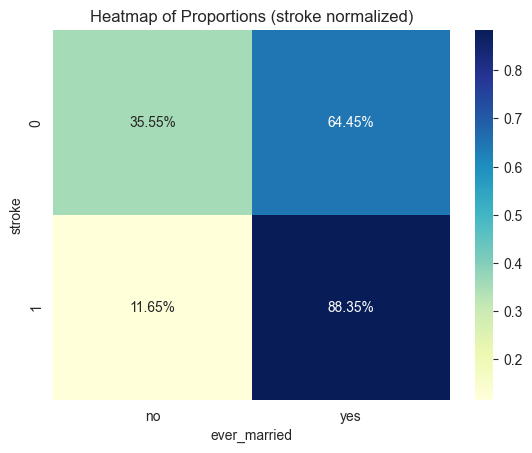

In [72]:
cat_cat_bva.plot_heatmap_contingency("stroke", "ever_married")

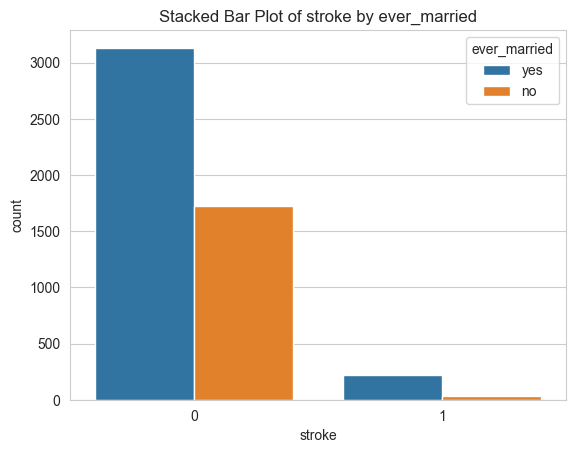

In [73]:
cat_cat_bva.plot_stacked_barplot_sns("stroke", "ever_married")

In [74]:
cat_cat_bva.test_chi_squared_independence("stroke", "ever_married")


--- Chi-squared Test for Independence (stroke vs ever_married) ---
Chi2 Statistic: 58.9239
P-value: 0.0000
Degrees of Freedom: 1
Result: Significant dependence found (reject H0). There IS a relationship between the variables.


In [75]:
cat_cat_bva.calculate_cramers_v("stroke", "ever_married")


--- Cramer's V Association Strength (stroke vs ever_married) ---
Cramer's V: 0.1074


0.10738293153083231

- marrige has significant relation with heart stroke

### 5. Stroke Vs. Work Type

In [76]:
cat_cat_bva.create_contingency_table("stroke", "work_type")


--- Contingency Table (Counts) for stroke vs work_type ---


work_type,children,govt_job,never_worked,private,self_employed
stroke,,,,,
0,685,624,22,2776,754
1,2,33,0,149,65


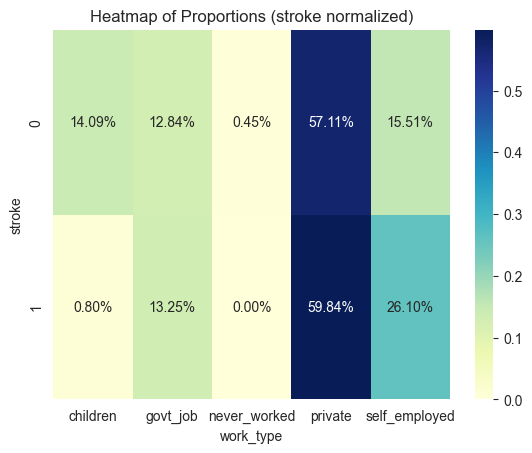

In [77]:
cat_cat_bva.plot_heatmap_contingency("stroke", "work_type")

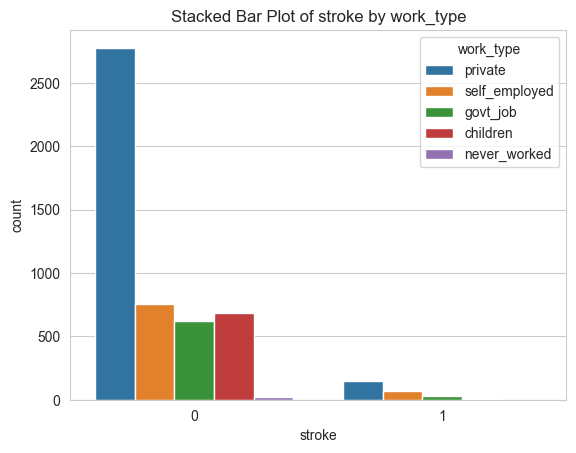

In [78]:
cat_cat_bva.plot_stacked_barplot_sns("stroke", "work_type")

In [79]:
cat_cat_bva.test_chi_squared_independence("stroke", "work_type")


--- Chi-squared Test for Independence (stroke vs work_type) ---
Chi2 Statistic: 49.1635
P-value: 0.0000
Degrees of Freedom: 4
Result: Significant dependence found (reject H0). There IS a relationship between the variables.


In [80]:
cat_cat_bva.calculate_cramers_v("stroke", "work_type")


--- Cramer's V Association Strength (stroke vs work_type) ---
Cramer's V: 0.0981


0.09808689782926237

- type of work has significant relation with heart stroke

### 6. Stroke Vs. Residence Type

In [81]:
cat_cat_bva.create_contingency_table("stroke", "residence_type")


--- Contingency Table (Counts) for stroke vs residence_type ---


residence_type,rural,urban
stroke,,
0,2400,2461
1,114,135


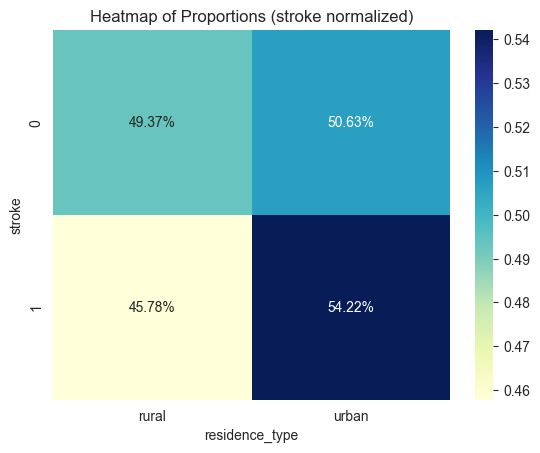

In [82]:
cat_cat_bva.plot_heatmap_contingency("stroke", "residence_type")

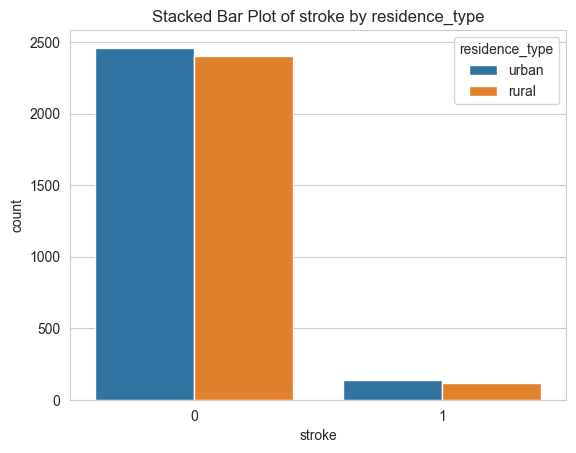

In [83]:
cat_cat_bva.plot_stacked_barplot_sns("stroke", "residence_type")

In [84]:
cat_cat_bva.test_chi_squared_independence("stroke", "residence_type")


--- Chi-squared Test for Independence (stroke vs residence_type) ---
Chi2 Statistic: 1.0816
P-value: 0.2983
Degrees of Freedom: 1
Result: No significant dependence found (fail to reject H0). Variables are likely independent.


In [85]:
cat_cat_bva.calculate_cramers_v("stroke", "residence_type")


--- Cramer's V Association Strength (stroke vs residence_type) ---
Cramer's V: 0.0145


0.014548903612081913

- residence is not having any significant relation with heart stroke

### 7. Stroke Vs. Smoking Status

In [86]:
cat_cat_bva.create_contingency_table("stroke", "smoking_status")


--- Contingency Table (Counts) for stroke vs smoking_status ---


smoking_status,formerly_smoked,never_smoked,not_available
stroke,,,
0,815,1802,747
1,70,90,42


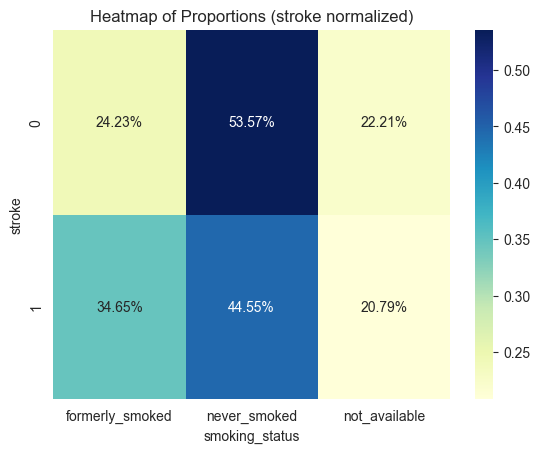

In [87]:
cat_cat_bva.plot_heatmap_contingency("stroke", "smoking_status")

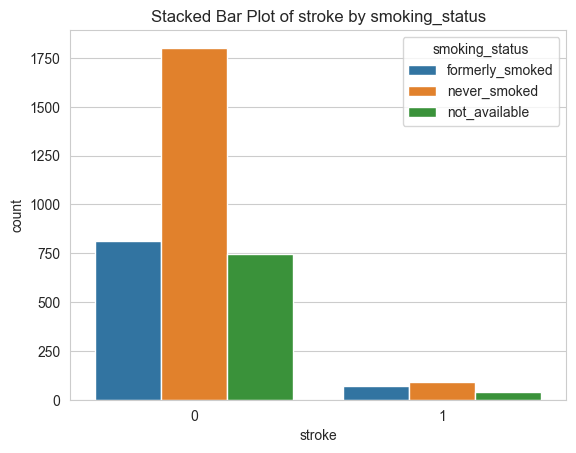

In [88]:
cat_cat_bva.plot_stacked_barplot_sns("stroke", "smoking_status")

In [89]:
cat_cat_bva.test_chi_squared_independence("stroke", "smoking_status")


--- Chi-squared Test for Independence (stroke vs smoking_status) ---
Chi2 Statistic: 11.4365
P-value: 0.0033
Degrees of Freedom: 2
Result: Significant dependence found (reject H0). There IS a relationship between the variables.


In [90]:
cat_cat_bva.calculate_cramers_v("stroke", "smoking_status")


--- Cramer's V Association Strength (stroke vs smoking_status) ---
Cramer's V: 0.0566


0.05663121730751331

- smoking status has significant relation with heart stroke

## **Final Conclusion:**

**Feature** | **Relation with Stroke**
--- | ---
 Gender | No
 Hypertension | Yes
 Heart Disease | Yes
 Ever Married | Yes
 Work Type | Yes
 Residence Type | No
 Smoking Status | Yes (missing values present)

## 3. Numerical - Numerical

- age
- avg_glucose_level
- bmi

In [91]:
num_num_bi = NumericalNumericalBivariate(df)

### 1. Age vs avg_glucose_level

In [92]:
import seaborn as sns

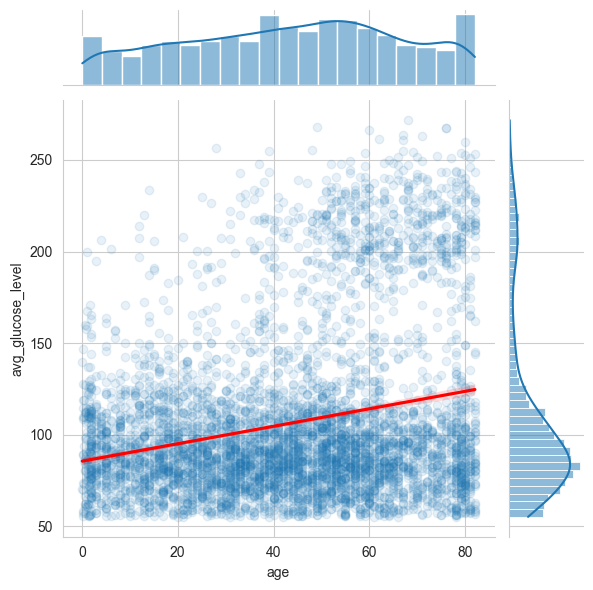

In [93]:
num_num_bi.plot_jointplot_sns("age", "avg_glucose_level", alpha=0.1)

In [94]:
num_num_bi.test_pearson_significance("age", "avg_glucose_level")


--- Pearson Correlation Significance Test ---
Statistic: 0.2382, P-value: 0.0000
Result: Significant correlation (reject null hypothesis of no correlation).


- after age > `40` and for different glucose levels heart stroke is possible

### 2. Age vs bmi

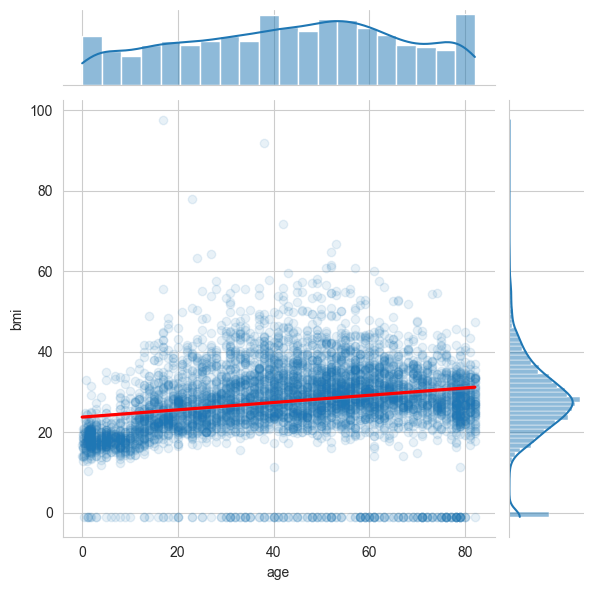

In [95]:
num_num_bi.plot_jointplot_sns("age", "bmi", alpha=0.1)

In [96]:
num_num_bi.test_pearson_significance("age", "bmi")


--- Pearson Correlation Significance Test ---
Statistic: 0.2126, P-value: 0.0000
Result: Significant correlation (reject null hypothesis of no correlation).


### 3. avg_glucose_level vs bmi

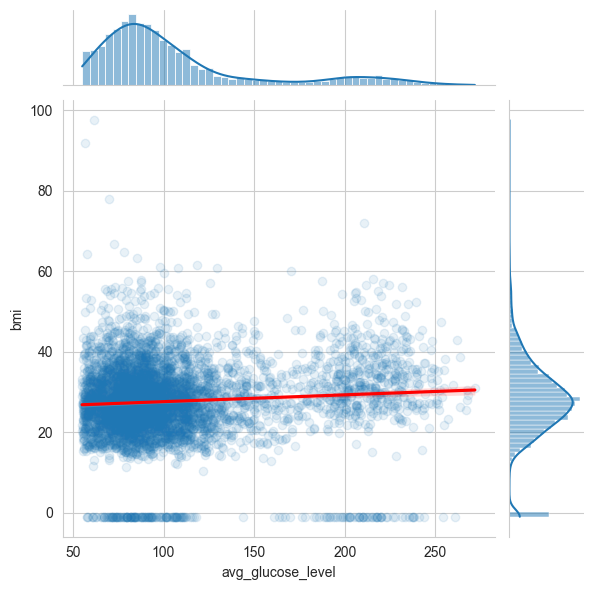

In [97]:
num_num_bi.plot_jointplot_sns("avg_glucose_level", "bmi", alpha=0.1)

In [98]:
num_num_bi.test_pearson_significance("avg_glucose_level", "bmi")


--- Pearson Correlation Significance Test ---
Statistic: 0.0793, P-value: 0.0000
Result: Significant correlation (reject null hypothesis of no correlation).


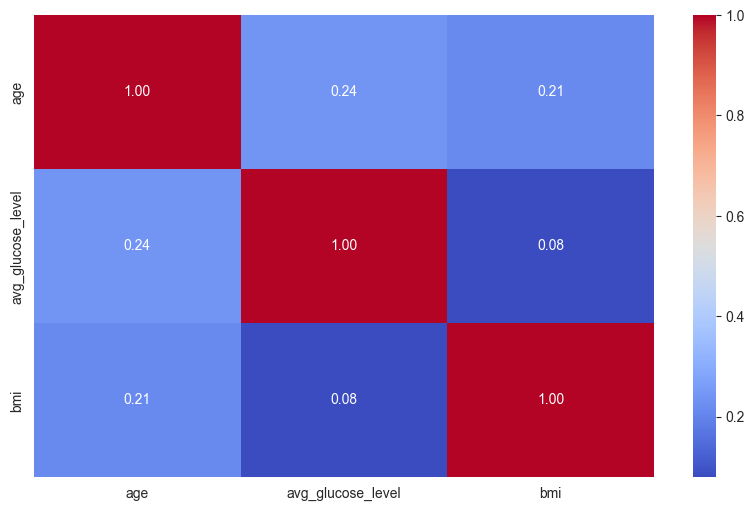

In [99]:
num_num_bi.plot_correlation_heatmap(["age", "avg_glucose_level", "bmi"])

### PairPlot

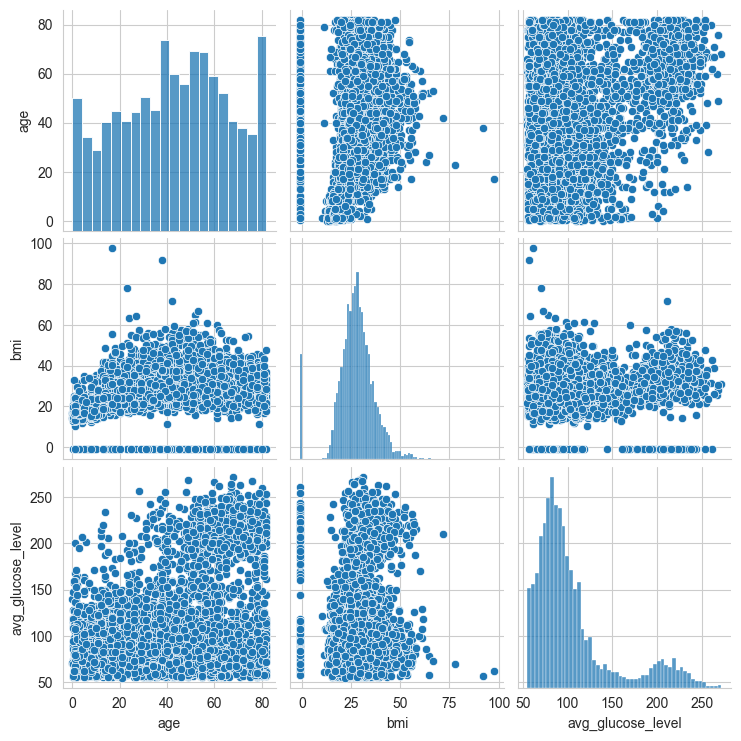

In [100]:
import seaborn as sns
sns.pairplot(df[["age", "bmi", "avg_glucose_level"]])

### **Final Conclusion:**

- all three numerical variables are inter correlated to each other

### **Next Action:**

- Missing value handling, imputation and re-validating current evidences